In [1]:
#easier to use notebook when getting started: using this for minor bits as I expand the database
# Krista 28 August 2026

In [1]:
%reset -f

In [1]:
from sqlalchemy import select, func, create_engine, text, union_all, union
from sqlalchemy.orm import sessionmaker, Session
from sqlalchemy import inspect, MetaData, Table
import pandas as pd
import matplotlib.pyplot as plt

import pdb

import models 
#from models import *
# import models as m

In [ ]:
# create a SQLite database engine
SQLALCHEMY_DATABASE_URL = "sqlite:///test_data/sargasso.db"
engine = create_engine(SQLALCHEMY_DATABASE_URL) #, echo=True) #(turn off echo, gets annoying)

# Create a session
Session = sessionmaker(bind=engine)
session = Session()

In [5]:
from sqlalchemy import select

# Define your models and their prefixes
model_configs = [
    (models.Discrete, 'D'),
    (models.NCBIonline, 'N')
]

select_columns = []

for model, prefix in model_configs:
    # Loop through every column mapped to the model's table
    for column in model.__table__.columns:
        
        # 1. Skip or keep specific names without labels (e.g., keys or contact fields)
        if column.name in ['bottleID', 'contact']:
            select_columns.append(column)
            
        # 2. Handle edge cases where column names differ slightly between models
        elif column.name == 'nominalDepth':
            select_columns.append(column.label(f"{prefix}depth"))
            
        # 3. Automatically label everything else (e.g., temp -> Dtemp, sal -> Dsal)
        else:
            select_columns.append(column.label(f"{prefix}{column.name}"))

# Execute the query with the unpacked list
query = (
    select(*select_columns)
    .join(
        models.NCBIinhouse, 
        models.Discrete.bottleID == models.NCBIinhouse.bottleID
    )
    .join(
        models.NCBIonline, 
        models.NCBIinhouse.biosample == models.NCBIonline.biosample
    )
)
df = pd.read_sql_query(query, con=engine)
df.shape

(1009, 27)

In [8]:
print(df.dtypes)


Did            int64
bottleID      object
Dcruise       object
Dcast         object
Dniskin       object
Dyyyymmdd     object
Dlat          object
Dlon          object
Ddepth        object
Dtemp         object
Dsal          object
Doxy          object
Ddensity      object
Dfluor        object
Nid            int64
contact       object
Nbiosample    object
Nsample       object
Nsra          object
Ndate         object
Ndepth        object
Nlat_lon      object
Ntemp         object
Nsal          object
Nfluor        object
Ndensity      object
Noxy          object
dtype: object


In [9]:
df['contact']= df['contact'].fillna('unknown')

In [10]:
makeNumber = ['temp','sal','depth','oxy','fluor','density']
im = [col for col in df.columns if any(kw in col.lower() for kw in makeNumber) ] 
im

['Ddepth',
 'Dtemp',
 'Dsal',
 'Doxy',
 'Ddensity',
 'Dfluor',
 'Ndepth',
 'Ntemp',
 'Nsal',
 'Nfluor',
 'Ndensity',
 'Noxy']

In [11]:
df[im] = df[im].apply(pd.to_numeric, errors='coerce')

In [12]:
print(df.dtypes)


Did             int64
bottleID       object
Dcruise        object
Dcast          object
Dniskin        object
Dyyyymmdd      object
Dlat           object
Dlon           object
Ddepth        float64
Dtemp         float64
Dsal          float64
Doxy          float64
Ddensity      float64
Dfluor        float64
Nid             int64
contact        object
Nbiosample     object
Nsample        object
Nsra           object
Ndate          object
Ndepth        float64
Nlat_lon       object
Ntemp         float64
Nsal          float64
Nfluor        float64
Ndensity      float64
Noxy          float64
dtype: object


In [13]:
df['contact'].unique()

array(['Luis Bolanos', 'Fabian Wittmers', 'Shuting Liu',
       'Leocadio Blanco-Bercial'], dtype=object)

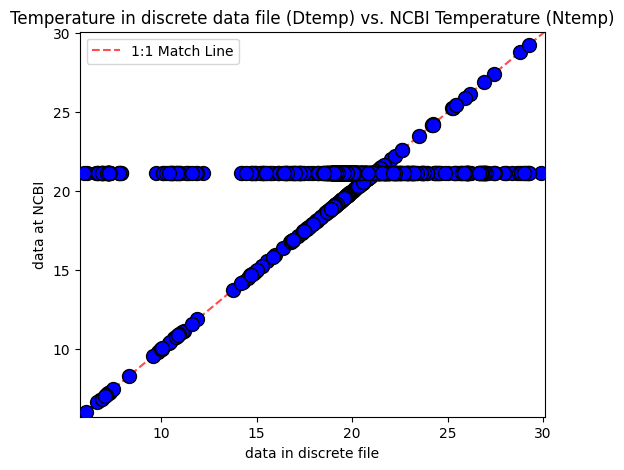

In [14]:
# Scatter plot to compare the two temperatures
plt.figure(figsize=(6, 5))
plt.scatter(df["Dtemp"], df["Ntemp"], color="blue", edgecolor="k", s=100, zorder=3)

# Add a 1:1 reference line to see where they perfectly match
min_val = min(df["Dtemp"].min(), df["Ntemp"].min()) - 0.2
max_val = max(df["Dtemp"].max(), df["Ntemp"].max()) + 0.2
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Temperature in discrete data file (Dtemp) vs. NCBI Temperature (Ntemp)")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

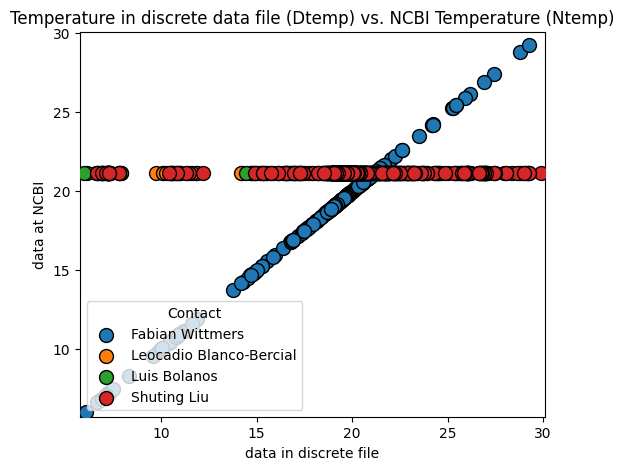

In [15]:
plt.figure(figsize=(6, 5))

# 1. Loop through unique categories in the contact column
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Dtemp"], 
        group["Ntemp"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# # 2. Add a 1:1 reference line
# min_val = min(df["Dtemp"].min(), df["Ntemp"].min()) - 0.2
# max_val = max(df["Dtemp"].max(), df["Ntemp"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 3. Labeling and grid (plt.legend() will now show the text categories)
plt.title("Temperature in discrete data file (Dtemp) vs. NCBI Temperature (Ntemp)")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.legend(title="Contact",loc='lower left')

plt.show()


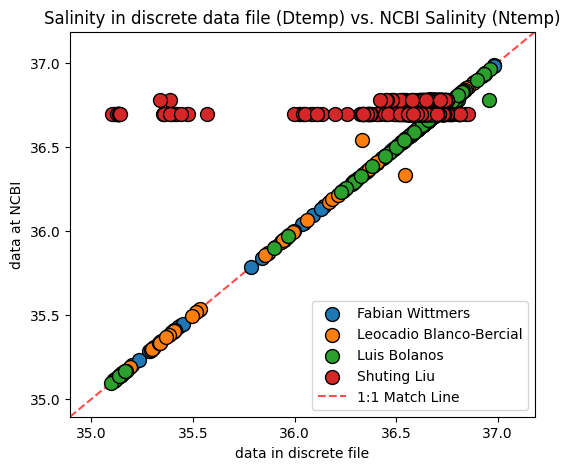

In [16]:
# and with depth?
# Scatter plot to compare the two temperatures
plt.figure(figsize=(6, 5))
#plt.scatter(df["Dsal"], df["Nsal"], color="blue", edgecolor="k", s=100, zorder=3)
# Loop through unique categories in the contact column
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Dsal"], 
        group["Nsal"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )



# Add a 1:1 reference line to see where they perfectly match
min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Salinity in discrete data file (Dtemp) vs. NCBI Salinity (Ntemp)")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

In [17]:
im

['Ddepth',
 'Dtemp',
 'Dsal',
 'Doxy',
 'Ddensity',
 'Dfluor',
 'Ndepth',
 'Ntemp',
 'Nsal',
 'Nfluor',
 'Ndensity',
 'Noxy']

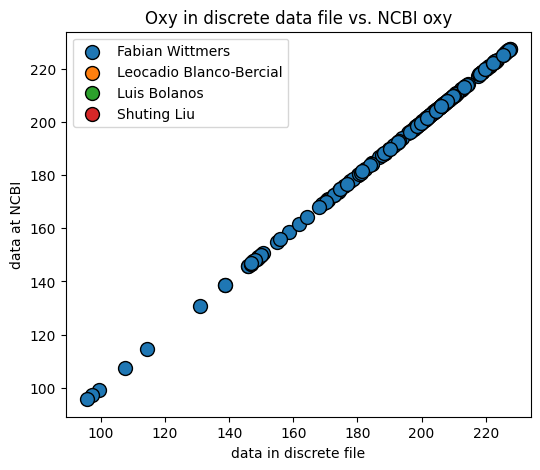

In [18]:
# Scatter plot to compare the two oxygen
plt.figure(figsize=(6, 5))
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Doxy"], 
        group["Noxy"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# # Add a 1:1 reference line to see where they perfectly match
# min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
# max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Oxy in discrete data file vs. NCBI oxy")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

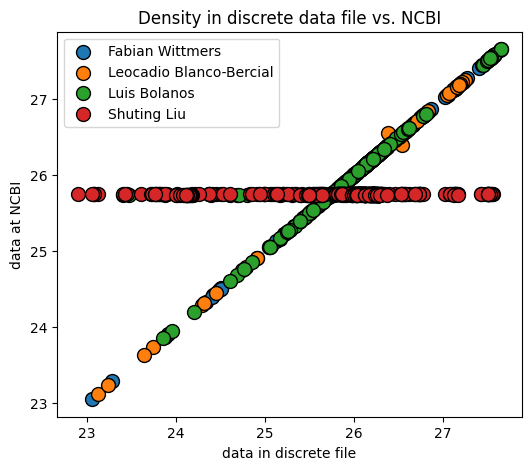

In [19]:
# Scatter plot to compare the two oxygen
plt.figure(figsize=(6, 5))
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Ddensity"], 
        group["Ndensity"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# # Add a 1:1 reference line to see where they perfectly match
# min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
# max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Density in discrete data file vs. NCBI")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

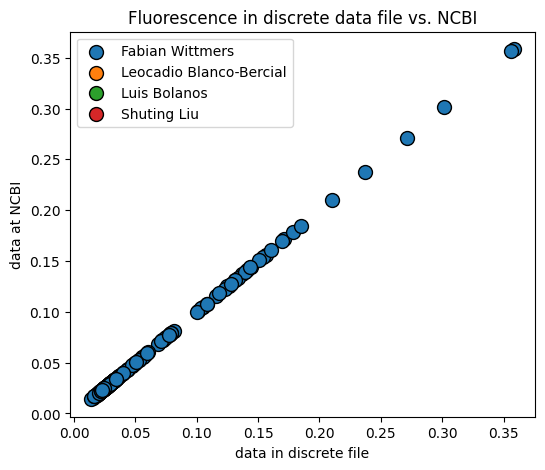

In [20]:
# Scatter plot to compare the two oxygen
plt.figure(figsize=(6, 5))
for name, group in df.groupby("contact"):
    plt.scatter(
        group["Dfluor"], 
        group["Nfluor"], 
        label=name,     # Automatically handles the legend labels
        edgecolor="k", 
        s=100, 
        zorder=3
    )

# # Add a 1:1 reference line to see where they perfectly match
# min_val = min(df["Dsal"].min(), df["Nsal"].min()) - 0.2
# max_val = max(df["Dsal"].max(), df["Nsal"].max()) + 0.2
# plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", alpha=0.7, label="1:1 Match Line")

# 4. Labeling and grid
plt.title("Fluorescence in discrete data file vs. NCBI")
plt.xlabel("data in discrete file")
plt.ylabel("data at NCBI")
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

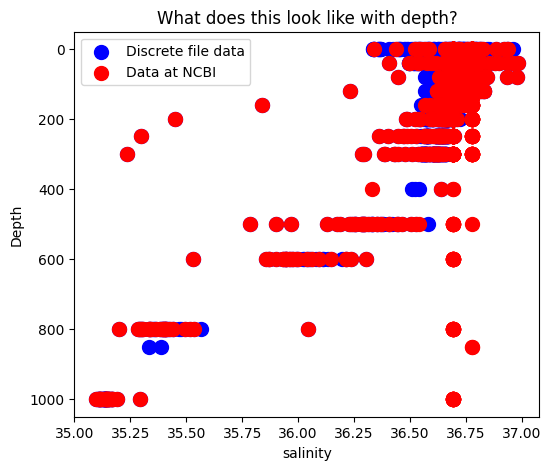

In [42]:
# Plot with detph
plt.figure(figsize=(6, 5))
plt.scatter(df["Dsal"], df["Ddepth"], color="blue", edgecolor="blue", s=100, zorder=3,label='Discrete file data')
plt.scatter(df["Nsal"], df["Ddepth"], color="red", edgecolor="red", s=100, zorder=3,label='Data at NCBI')

# Labeling and grid
plt.title("What does this look like with depth?")
plt.xlabel("salinity")
plt.ylabel("Depth")
plt.gca().invert_yaxis()
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

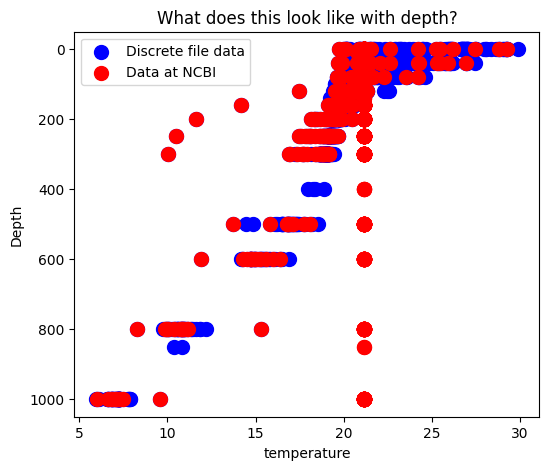

In [41]:
# Plot with detph
plt.figure(figsize=(6, 5))
plt.scatter(df["Dtemp"], df["Ddepth"], color="blue", edgecolor="blue", s=100, zorder=3,label='Discrete file data')
plt.scatter(df["Ntemp"], df["Ddepth"], color="red", edgecolor="red", s=100, zorder=3,label= 'Data at NCBI')

# Labeling and grid
plt.title("What does this look like with depth?")
plt.xlabel("temperature")
plt.ylabel("Depth")
plt.gca().invert_yaxis()
# plt.xlim(min_val, max_val)
# plt.ylim(min_val, max_val)
#plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.show()

In [3]:
#Make sure I think I have what I need:
for mapper in models.Base.registry.mappers:
    print(mapper.class_.__name__)

SeqV1V2
LTTdeep
SeqBasics
MtabUntargetedInfo
LTTs1
Discrete
CyverseInfo
MetaboliteInfo
SeqV4_16S
SeqV4_18S
NCBIonline
NCBIunreleased
NCBIinhouse


In [8]:
from sqlalchemy import create_engine
from sqlalchemy.ext.automap import automap_base

# 1. Reset the engine connection pool
if 'engine' in globals():
    engine.dispose()
engine = create_engine('sqlite:///test_data/sargasso.db')

# 2. CRITICAL: Initialize a completely NEW Base object to drop old classes
Base = automap_base()

# 3. Reflect from scratch
Base.prepare(autoload_with=engine)

# Your updated classes will now be freshly populated
print(Base.classes.keys()) 

['seqV1V2', 'cyverse', 'seqV4_16S', 'seqV4_18S', 'compositeV1V2', 'NCBIonline', 'NCBIunreleased', 'discrete', 'metabolitesUntargeted', 'LTTs1', 'seqBasics', 'LTTdeep', 'metabolites', 'NCBIinhouse']


In [9]:
query = (
    select(models.NCBIunreleased)  # Pull records 
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df)

        id     biosample      sraV1V2       title             bottleID
0        1  SAMN44822507  SRR31399175  1037600411         BSV4_695_S42
1        2  SAMN44822506  SRR31399176  1037600410         BSV4_694_S41
2        3  SAMN44822505  SRR31399177  1037600408         BSV4_693_S40
3        4  SAMN44822504  SRR31399178  1037600407         BSV4_692_S39
4        5  SAMN44822503  SRR31399179  1037600404         BSV4_691_S38
...    ...           ...          ...         ...                  ...
1781  1782  SAMN22786474  SRR16704108   10337_200    1033701713_18S_V4
1782  1783  SAMN22786469  SRR16704113   10336_800    1033601321_18S_V4
1783  1784  SAMN22169891         None  BS_138_S46  1033901109_16S_V1V2
1784  1785  SAMN22786665  SRR16704263    20345_80    2034500505_18S_V4
1785  1786  SAMN22786321  SRR16704316     10321_1    1032100301_18S_V4

[1786 rows x 5 columns]


In [10]:
#just tell me what is in a table
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(models.LTTdeep)
    .where(
        models.LTTdeep.biosample == 'SAMN52634534'
    )
)

df = pd.read_sql_query(query, con=engine)
df

,id,sample,biosample,sraV1V2,year,month,depth,bottleID
0,1,35_0M_S1,SAMN52634534,SRR36513417,1991,8,0,1003500112


In [11]:
#just tell me what is in a table
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(models.LTTdeep)
    .where(
        models.LTTdeep.bottleID == '1037101511'
    )
)

df = pd.read_sql_query(query, con=engine)
df

,id,sample,biosample,sraV1V2,year,month,depth,bottleID
0,10,371_0M_S27,SAMN52634710,SRR36513396,2020,8,0,1037101511
1,22,371_200M_S28,SAMN52634905,SRR36513403,2020,8,200,1037101511


In [12]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(models.LTTdeep, models.NCBIinhouse)
    .join(
        models.NCBIinhouse,
        models.NCBIinhouse.biosample == models.LTTdeep.biosample
    )
)

df = pd.read_sql_query(query, con=engine)
df.shape

(6, 19)

In [13]:
print(df)

   id        sample     biosample      sraV1V2  year month depth    bottleID  \
0   7     332_0M_S7  SAMN22169716  SRR36513399  2017     1     0  1033201501   
1   8    350_0M_S11  SAMN28811517  SRR36513398  2018     8     0  1035001601   
2   9    362_0M_S23  SAMN36323002  SRR36513397  2019     8     0  1036202201   
3  18   332_200M_S8  SAMN22169721  SRR36513408  2017     1   200  1033201511   
4  19  357_200M_S22  SAMN36322946  SRR36513407  2019     3   200  1035700711   
5  20  362_200M_S24  SAMN36323006  SRR36513406  2019     8   200  1036202211   

   id_1   biosample_1 cruise5 sampleV1V2    sraV1V2_1  \
0   277  SAMN22169716   10332    10332_1  SRR16297311   
1   702  SAMN28811517   10350    10350_1  SRR19520206   
2   954  SAMN36323002   10362    10362_1  SRR27540812   
3   283  SAMN22169721   10332  10332_200  SRR16297305   
4   791  SAMN36322946   10357  10357_200  SRR27540837   
5   959  SAMN36323006   10362  10362_200  SRR27540807   

                                       

In [14]:
# 1. Modify the query to perform a LEFT OUTER JOIN and filter for missing records
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.NCBIinhouse,
        models.NCBIinhouse.biosample == models.LTTdeep.biosample,
        isouter=True  # 👈 This turns the join into a LEFT JOIN
    )
    .where(
        models.NCBIinhouse.biosample == None  # 👈 Filters for records NOT found in NCBIinhouse
    )
)

# 2. Safely execute the query using a connection context manager
with engine.connect() as connection:
    df_not_found = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df_not_found)

    id        sample     biosample      sraV1V2  year month depth    bottleID
0    1      35_0M_S1  SAMN52634534  SRR36513417  1991     8     0  1003500112
1    2      42_0M_S3  SAMN52634541  SRR36513416  1992     3     0  1004200312
2    3      46_0M_S5  SAMN52634545  SRR36513405  1992     7     0  1004600212
3    4     47_0M_S17  SAMN52634546  SRR36513402  1992     8     0  1004700312
4    5     56_0M_S15  SAMN52634555  SRR36513401  1993     5     0  1005600312
5    6     65_0M_S19  SAMN52634562  SRR36513400  1994     2     0  1006500601
6   10    371_0M_S27  SAMN52634710  SRR36513396  2020     8     0  1037101511
7   11    35_200M_S2  SAMN52634711  SRR36513415  1991     8   200  1003500102
8   12    42_200M_S4  SAMN52634718  SRR36513414  1992     3   200  1004200302
9   13    46_200M_S6  SAMN52634722  SRR36513413  1992     7   200  1004600202
10  14   47_200M_S18  SAMN52634723  SRR36513412  1992     8   200  1004700302
11  15   54_200M_S10  SAMN52634729  SRR36513411  1993     3   20

In [15]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(models.LTTs1, models.NCBIinhouse)
    .join(
        models.NCBIinhouse,
        models.NCBIinhouse.biosample == models.LTTs1.biosample
    )
)

df = pd.read_sql_query(query, con=engine)
df.shape

(96, 18)

In [16]:
# 1. Modify the query to perform a LEFT OUTER JOIN and filter for missing records
query = (
    select(models.LTTs1)  # Pull records from LTTdeep
    .join(
        models.NCBIinhouse,
        models.NCBIinhouse.biosample == models.LTTs1.biosample,
        isouter=True  # 👈 This turns the join into a LEFT JOIN
    )
    .where(
        models.NCBIinhouse.biosample == None  # 👈 Filters for records NOT found in NCBIinhouse
    )
)

# 2. Safely execute the query using a connection context manager
with engine.connect() as connection:
    df_not_found = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df_not_found)

      id     biosample      sraV1V2  year month depth    bottleID
0      1  SAMN52634534  SRR35786328  1991     8     0  1003500112
1      2  SAMN52634535  SRR35786329  1991     9     0  1003600312
2      3  SAMN52634536  SRR35786133  1991    10     0  1003700112
3      4  SAMN52634537  SRR35786025  1991    11     0  1003800112
4      5  SAMN52634538  SRR35786055  1991    12     0  1003900112
..   ...           ...          ...   ...   ...   ...         ...
361  454  SAMN52634903  SRR35786001  2020     7   200  1036901711
362  456  SAMN52634904  SRR35786059  2020     7   200  1037000611
363  458  SAMN52634905  SRR35786058  2020     8   200  1037101511
364  460  SAMN52634614  SRR35786193  2002     3     0  2016200201
365  461  SAMN52634793  SRR35786259  2002     3   200  2016200221

[366 rows x 7 columns]


In [17]:
#essentially making two small tables so I can stack them
gIsR = select(models.NCBIonline.id, 
              models.NCBIonline.biosample, 
              models.NCBIonline.sra.label('sra'))
gNotR = select(models.NCBIunreleased.id, 
               models.NCBIunreleased.biosample, 
               models.NCBIunreleased.sraV1V2.label('sra'))


# NCBIcombined = union(gNotR,gIsR) #by selecting union, the duplicates will be removed (though there should be none, but there are bc the SRA turns out to be different in places)
NCBIcombined = union_all(gNotR,gIsR)

#now make the stacked table into a subquery, this is needed to we can actually query it (otherwise can only print as shown above)
NCBI_forQuery = NCBIcombined.subquery()

with engine.connect() as conn:
    df = pd.read_sql_query(NCBIcombined,con = conn)

#print(df)
#df.to_excel('test_data/merge.xlsx')

In [18]:
#one SRA should only have one biosample
mismatched_sra = (
    select(NCBI_forQuery.c.sra)
    .group_by(NCBI_forQuery.c.sra)
    .having(func.count(NCBI_forQuery.c.biosample.distinct()) > 1)
    .subquery()
)

# Fetch all rows belonging to those conflicting biosamples
query = (
    select(NCBI_forQuery)
    .where(NCBI_forQuery.c.sra.in_(select(mismatched_sra.c.sra)))
    .order_by(NCBI_forQuery.c.sra)
)

with engine.connect() as conn:
    df = pd.read_sql_query(query,con = conn)

print(df)
#df.to_excel('test_data/cd.xlsx')

#this is good news - each SRA only matches on biosample, check that as OK and move one

Empty DataFrame
Columns: [id, biosample, sra]
Index: []


In [19]:
#actually, never mind, this is not necessarily a problem one biosample can have many SRAs, but one SRA should only have one biosample
# Create a subquery of just the duplicate biosample IDs
mismatched_biosamples = (
    select(NCBI_forQuery.c.biosample)
    .group_by(NCBI_forQuery.c.biosample)
    .having(func.count(NCBI_forQuery.c.sra.distinct()) > 1)
    .subquery()
)

# Fetch all rows belonging to those conflicting biosamples
detailed_conflict_query = (
    select(NCBI_forQuery)
    .where(NCBI_forQuery.c.biosample.in_(select(mismatched_biosamples.c.biosample)))
    .order_by(NCBI_forQuery.c.biosample)
)

with engine.connect() as conn:
    df = pd.read_sql_query(detailed_conflict_query,con = conn)

print(df)
df.to_excel('test_data/c.xlsx')

        id     biosample          sra
0     1366  SAMN22169531  SRR16297535
1     1411  SAMN22169531  SRS10532025
2     1590  SAMN22169532  SRR16297534
3     1410  SAMN22169532  SRS10532026
4     1758  SAMN22169533  SRR16297295
...    ...           ...          ...
2031     3  SAMN44822553  SRS23255798
2032    93  SAMN44822554  SRR31399283
2033     2  SAMN44822554  SRS23255800
2034    92  SAMN44822555  SRR31399282
2035     1  SAMN44822555  SRS23255801

[2036 rows x 3 columns]


In [20]:
#now, find the error I know exists: does LTTdeep have a unique set of Biosamples? and SampleID (I know there is a duplicated SampleID)
queryDups = (
    select(models.LTTdeep)
    .group_by(models.LTTdeep.bottleID)
    .having(func.count(models.LTTdeep.bottleID) > 1)
)

with engine.connect() as conn:
    df = pd.read_sql_query(queryDups,con = conn)

print(df)

   id      sample     biosample      sraV1V2  year month depth    bottleID
0  10  371_0M_S27  SAMN52634710  SRR36513396  2020     8     0  1037101511


In [21]:
#essentially making two small tables so I can stack them
gIsR = select(models.NCBIonline.id, 
              models.NCBIonline.biosample, 
              models.NCBIonline.sra.label('sra'))
gNotR = select(models.NCBIunreleased.id, 
               models.NCBIunreleased.biosample, 
               models.NCBIunreleased.sraV1V2.label('sra'))


# NCBIcombined = union(gNotR,gIsR) #by selecting union, the duplicates will be removed (though there should be none, but there are bc the SRA turns out to be different in places)
NCBIcombined = union_all(gNotR,gIsR)

#now make the stacked table into a subquery, this is needed to we can actually query it (otherwise can only print as shown above)
NCBI_forQuery = NCBIcombined.subquery()

In [22]:
# 1. Modify the query to perform a LEFT OUTER JOIN and filter for missing records
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.NCBIonline,
        models.NCBIonline.biosample == models.LTTdeep.biosample,
        isouter=True  # 👈 This turns the join into a LEFT JOIN
    )
    .where(
        models.NCBIonline.biosample == None  # 👈 Filters for records NOT found in NCBIonline
    )
)

# 2. Safely execute the query using a connection context manager
with engine.connect() as connection:
    df_not_found = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df_not_found)

    id        sample     biosample      sraV1V2  year month depth    bottleID
0    1      35_0M_S1  SAMN52634534  SRR36513417  1991     8     0  1003500112
1    2      42_0M_S3  SAMN52634541  SRR36513416  1992     3     0  1004200312
2    3      46_0M_S5  SAMN52634545  SRR36513405  1992     7     0  1004600212
3    4     47_0M_S17  SAMN52634546  SRR36513402  1992     8     0  1004700312
4    5     56_0M_S15  SAMN52634555  SRR36513401  1993     5     0  1005600312
5    6     65_0M_S19  SAMN52634562  SRR36513400  1994     2     0  1006500601
6   10    371_0M_S27  SAMN52634710  SRR36513396  2020     8     0  1037101511
7   11    35_200M_S2  SAMN52634711  SRR36513415  1991     8   200  1003500102
8   12    42_200M_S4  SAMN52634718  SRR36513414  1992     3   200  1004200302
9   13    46_200M_S6  SAMN52634722  SRR36513413  1992     7   200  1004600202
10  14   47_200M_S18  SAMN52634723  SRR36513412  1992     8   200  1004700302
11  15   54_200M_S10  SAMN52634729  SRR36513411  1993     3   20

In [23]:
#do the reverse, what is found in NCBIonline (seems like it should nothing if they are all in NCBIunreleased)
# 1. Modify the query to perform a LEFT OUTER JOIN and filter for missing records
#different way to do this, first query to get all forws of NCBI online (seems to just make the table into something I can query)

#ncbi = select(models.NCBIonline.biosample).subquery()

#then get the things in models.LTTdeep that match
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.NCBIonline,
        models.LTTdeep.biosample == models.NCBIonline.biosample
        )
    .distinct()
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df)
#...so, fine, some of the biosamples are already online ...but careful, as LTTdeep should have SRAs that are not online

   id        sample     biosample      sraV1V2  year month depth    bottleID
0   7     332_0M_S7  SAMN22169716  SRR36513399  2017     1     0  1033201501
1   8    350_0M_S11  SAMN28811517  SRR36513398  2018     8     0  1035001601
2   9    362_0M_S23  SAMN36323002  SRR36513397  2019     8     0  1036202201
3  18   332_200M_S8  SAMN22169721  SRR36513408  2017     1   200  1033201511
4  19  357_200M_S22  SAMN36322946  SRR36513407  2019     3   200  1035700711
5  20  362_200M_S24  SAMN36323006  SRR36513406  2019     8   200  1036202211


In [24]:
#really should be looking for the SRAs...though I have to get back to the is the biosample-SRA link always the same
#then get the things in models.LTTdeep that match
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.NCBIonline,
        models.LTTdeep.sraV1V2 == models.NCBIonline.sra
        )
    .distinct()
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df)
#as expected, the SRAs in LTTdeep are not yet online...are they all in my pending list?

Empty DataFrame
Columns: [id, sample, biosample, sraV1V2, year, month, depth, bottleID]
Index: []


In [25]:
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.NCBIunreleased,
        models.LTTdeep.sraV1V2 == models.NCBIunreleased.sraV1V2
        )
    .distinct()
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df)
#they are also not in the NCBIunreleased ... ah, I see, some sequences in the unreleased list from NCBI do not have SRA 
# (though others do have an SRA, no idea what is going on there); regardless search next on bottleID

Empty DataFrame
Columns: [id, sample, biosample, sraV1V2, year, month, depth, bottleID]
Index: []


In [26]:
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.NCBIunreleased,
        models.LTTdeep.bottleID == models.NCBIunreleased.bottleID
        )
    .distinct()
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records
print(df)

    id        sample     biosample      sraV1V2  year month depth    bottleID
0    1      35_0M_S1  SAMN52634534  SRR36513417  1991     8     0  1003500112
1    2      42_0M_S3  SAMN52634541  SRR36513416  1992     3     0  1004200312
2    3      46_0M_S5  SAMN52634545  SRR36513405  1992     7     0  1004600212
3    4     47_0M_S17  SAMN52634546  SRR36513402  1992     8     0  1004700312
4    5     56_0M_S15  SAMN52634555  SRR36513401  1993     5     0  1005600312
5    6     65_0M_S19  SAMN52634562  SRR36513400  1994     2     0  1006500601
6   10    371_0M_S27  SAMN52634710  SRR36513396  2020     8     0  1037101511
7   11    35_200M_S2  SAMN52634711  SRR36513415  1991     8   200  1003500102
8   12    42_200M_S4  SAMN52634718  SRR36513414  1992     3   200  1004200302
9   13    46_200M_S6  SAMN52634722  SRR36513413  1992     7   200  1004600202
10  14   47_200M_S18  SAMN52634723  SRR36513412  1992     8   200  1004700302
11  15   54_200M_S10  SAMN52634729  SRR36513411  1993     3   20

In [27]:
#now, next question, do all the biosamples in LTTdeep appear in LTTs1?
# Setup the query
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.LTTs1,
        models.LTTs1.biosample == models.LTTdeep.biosample,
        isouter=True  # 👈 This turns the join into a LEFT JOIN
    )
    .where(
        models.LTTs1.biosample == None  # 👈 Filters for records NOT found in LTTs1
    )
)

# 2. Safely execute the query using a connection context manager
with engine.connect() as connection:
    df_not_found = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df_not_found)

   id      sample     biosample      sraV1V2  year month depth    bottleID
0  10  371_0M_S27  SAMN52634710  SRR36513396  2020     8     0  1037101511


In [28]:
#In Table S1 there are cases where two biosamples are on the same line: biosample1/biosample2...
#need to figure out how to pull those apart.
##split them at the database generation step, now move on to search
#...that sample is clearly an issue...no Biosample match in Table S1 is that biosample anywhere?
one = 'SAMN52634710'

In [29]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(
        models.LTTdeep,
    )       
    .where(
        models.LTTdeep.biosample == one
    )
)

df = pd.read_sql_query(query, con=engine)
df

,id,sample,biosample,sraV1V2,year,month,depth,bottleID
0,10,371_0M_S27,SAMN52634710,SRR36513396,2020,8,0,1037101511


In [30]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(
        models.NCBIunreleased,
    )       
    .where(
        models.NCBIunreleased.biosample == one
    )
)

df = pd.read_sql_query(query, con=engine)
df

#also odd that there is no sra for this biosample

,id,biosample,sraV1V2,title,bottleID
0,237,SAMN52634710,None,10371_1,1037101501


In [31]:
#last check : does the bottleID in LTTdeep match what I think it should in the discrete file?
query = (
    select(models.LTTdeep,models.Discrete)  # Pull records from both tables
    .outerjoin(
        models.Discrete,
        models.LTTdeep.bottleID == models.Discrete.bottleID
        )
    .distinct()
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records
print(df)

    id        sample     biosample      sraV1V2  year month depth    bottleID  \
0    1      35_0M_S1  SAMN52634534  SRR36513417  1991     8     0  1003500112   
1    2      42_0M_S3  SAMN52634541  SRR36513416  1992     3     0  1004200312   
2    3      46_0M_S5  SAMN52634545  SRR36513405  1992     7     0  1004600212   
3    4     47_0M_S17  SAMN52634546  SRR36513402  1992     8     0  1004700312   
4    5     56_0M_S15  SAMN52634555  SRR36513401  1993     5     0  1005600312   
5    6     65_0M_S19  SAMN52634562  SRR36513400  1994     2     0  1006500601   
6    7     332_0M_S7  SAMN22169716  SRR36513399  2017     1     0  1033201501   
7    8    350_0M_S11  SAMN28811517  SRR36513398  2018     8     0  1035001601   
8    9    362_0M_S23  SAMN36323002  SRR36513397  2019     8     0  1036202201   
9   10    371_0M_S27  SAMN52634710  SRR36513396  2020     8     0  1037101511   
10  11    35_200M_S2  SAMN52634711  SRR36513415  1991     8   200  1003500102   
11  12    42_200M_S4  SAMN52

In [41]:
#essentially making two small tables so I can stack them
gIsR = select(models.compositeV1V2.id, 
              models.compositeV1V2.bottleID,
              models.compositeV1V2.cruise,
              models.compositeV1V2.cast,
              models.compositeV1V2.niskin)
gNotR = select(models.Discrete.id, 
              models.Discrete.bottleID,
              models.Discrete.cruise,
              models.Discrete.cast,
              models.Discrete.niskin)


discretecombined = union_all(gNotR,gIsR)

#now make the stacked table into a subquery, this is needed to we can actually query it (otherwise can only print as shown above)
discrete_forQuery = discretecombined.subquery()
# df_subquery = pd.read_sql_query(select(discrete_forQuery), session.bind)
# display(df_subquery)

In [44]:
#last check : does the bottleID in LTTdeep match what I think it should in the discrete file?
query = (
    select(models.LTTdeep,
           discrete_forQuery.c.bottleID)   # Pull records from both tables
    .outerjoin(
        discrete_forQuery,
        models.LTTdeep.bottleID == discrete_forQuery.c.bottleID
        )
    .distinct()
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records
# print(df)

In [45]:
#now, extra check, is there anything that does not match
###....and this should not be OK for LTTdeep as I am looking in V1V2...so deal with that in a minute
#last check : does the bottleID in LTTdeep match what I think it should in the discrete file?
query = (
    select(models.LTTdeep,
           discrete_forQuery.c.bottleID)   # Pull records from both tables
    .outerjoin(
        discrete_forQuery,
        models.LTTdeep.bottleID == discrete_forQuery.c.bottleID
        )
    .where(
        models.LTTdeep.bottleID == None
    )
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records
print(df)

Empty DataFrame
Columns: [id, sample, biosample, sraV1V2, year, month, depth, bottleID, bottleID_1]
Index: []


In [43]:
df.to_excel('test_data/rous2.xlsx')

In [48]:
#last check : does the bottleID in LTTdeep match what I think it should in the discrete file?
query = (
    select(models.LTTs1,
           discrete_forQuery.c.bottleID)   # Pull records from both tables
    .outerjoin(
        discrete_forQuery,
        models.LTTs1.bottleID == discrete_forQuery.c.bottleID
        )
    .distinct()
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records
print(df)
df.to_excel('test_data/asdfa.xlsx')

      id     biosample      sraV1V2  year month depth    bottleID  bottleID_1
0      1  SAMN52634534  SRR35786328  1991     8     0  1003500112        None
1      2  SAMN52634535  SRR35786329  1991     9     0  1003600312        None
2      3  SAMN52634536  SRR35786133  1991    10     0  1003700112        None
3      4  SAMN52634537  SRR35786025  1991    11     0  1003800112        None
4      5  SAMN52634538  SRR35786055  1991    12     0  1003900112        None
..   ...           ...          ...   ...   ...   ...         ...         ...
457  458  SAMN52634905  SRR35786058  2020     8   200  1037101511  1037101511
458  459  SAMN44822466  SRR35786058  2020     8   200  1037101511  1037101511
459  460  SAMN52634614  SRR35786193  2002     3     0  2016200201        None
460  461  SAMN52634793  SRR35786259  2002     3   200  2016200221        None
461  462  SAMN22169680  SRR16297383  2016    10     1  1032901101  1032901101

[462 rows x 8 columns]


In [47]:
#now, extra check, is there anything that does not match
###....and this should not be OK for LTTdeep as I am looking in V1V2...so deal with that in a minute
#last check : does the bottleID in LTTdeep match what I think it should in the discrete file?
query = (
    select(models.LTTs1,
           discrete_forQuery.c.bottleID)   # Pull records from both tables
    .outerjoin(
        discrete_forQuery,
        models.LTTs1.bottleID == discrete_forQuery.c.bottleID
        )
    .where(
        models.LTTs1.bottleID == None
    )
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records
print(df)

Empty DataFrame
Columns: [id, biosample, sraV1V2, year, month, depth, bottleID, bottleID_1]
Index: []


In [33]:
#don't seem to be in unreleased...are they inhouse?
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.NCBIinhouse,
        models.LTTdeep.sraV1V2 == models.NCBIinhouse.sraV1V2
        )
    .distinct()
)

# Run the query and make a dataframe
with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df)
#no...is this a coding issue or missing samples ?

Empty DataFrame
Columns: [id, sample, biosample, sraV1V2, year, month, depth, bottleID]
Index: []


In [34]:
# 1. Modify the query to perform a LEFT OUTER JOIN and filter for missing records
query = (
    select(models.LTTdeep)  # Pull records from LTTdeep
    .join(
        models.NCBIunreleased,
        models.NCBIunreleased.biosample == models.LTTdeep.biosample,
        isouter=True  # 👈 This turns the join into a LEFT JOIN
    )
    .where(
        models.NCBIunreleased.biosample == None  # 👈 Filters for records NOT found in NCBIinhouse
    )
)

# 2. Safely execute the query using a connection context manager
with engine.connect() as connection:
    df_not_found = pd.read_sql_query(query, con=connection)

# 3. View the records that failed to match
print(df_not_found)

#this is good - the biosamples in LTTdeep are currently all in NCBIunreleased, which is fine

Empty DataFrame
Columns: [id, sample, biosample, sraV1V2, year, month, depth, bottleID]
Index: []


In [35]:
#
queryDups = (
    select(NCBI_forQuery.c.biosample)
    .group_by(NCBI_forQuery.c.biosample)
    .having(func.count(NCBI_forQuery.c.biosample) > 1)
)

with engine.connect() as conn:
    df = pd.read_sql_query(queryDups,con = conn)

print(df)

         biosample
0     SAMN22169531
1     SAMN22169532
2     SAMN22169533
3     SAMN22169534
4     SAMN22169535
...            ...
1406  SAMN44822551
1407  SAMN44822552
1408  SAMN44822553
1409  SAMN44822554
1410  SAMN44822555

[1411 rows x 1 columns]


In [ ]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(
        models.LTTdeep,
    )       
    .where(
        models.LTTdeep.bottleID == '1037101511'
    )
)

df = pd.read_sql_query(query, con=engine)
df

In [ ]:


#then, this is the query I need to see how much of Table LLTdeep is on our list for NCBI released information
query = (
    select(models.LTTdeep, NCBI_forQuery)
    .join(
        NCBI_forQuery,
        NCBI_forQuery.c.biosample == models.LTTdeep.biosample
    )
)

with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

print(df)
#save this as Excel file so I can check myself
df.to_excel('test_data/checkLTTdeep3.xlsx')

In [ ]:
#now do the reverse, what is NOT in NCBI released information but is in LTTdeep:
query = (
    select(models.LTTdeep)
    .join(
        NCBI_forQuery,
        NCBI_forQuery.c.biosample == models.LTTdeep.biosample,
        isouter = True    
    )
    .where(NCBI_forQuery.c.biosample == None)
)

with engine.connect() as connection:
    df = pd.read_sql_query(query, con=connection)

print(df)

In [ ]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(models.NCBIinhouse)
    .where(
        models.NCBIinhouse.biosample == 'check discrepancy'
    )
)

df = pd.read_sql_query(query, con=engine)
# df
df.shape

In [ ]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(
        models.NCBIinhouse.biosample.label('biosample'),
        models.NCBIinhouse.bottleID.label('bottleID'),
        models.NCBIinhouse.sraV1V2.label('sraV1V2'),
        models.NCBIonline.biosample.label('o_biosample'),
        models.NCBIonline.sra.label('o_sra')
    )
    .join(    
        models.NCBIonline,
        models.NCBIonline.biosample == models.NCBIinhouse.biosample,
        isouter = True
    )        
    .where(
        models.NCBIinhouse.biosample == 'check discrepancy'
    )
)

df = pd.read_sql_query(query, con=engine)
df

In [ ]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(
        models.NCBIinhouse.biosample.label('biosample'),
        models.NCBIinhouse.bottleID.label('bottleID'),
        models.NCBIinhouse.sraV1V2.label('sraV1V2'),
        models.NCBIonline.biosample.label('o_biosample'),
        models.NCBIonline.sra.label('o_sra')
    )
    .join(    
        models.NCBIonline,
        models.NCBIonline.sra == models.NCBIinhouse.sraV1V2,
        isouter = True
    )        
    .where(
        models.NCBIinhouse.biosample == 'check discrepancy'
    )
)

df = pd.read_sql_query(query, con=engine)
df

In [ ]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(
        models.NCBIinhouse.biosample.label('biosample'),
        models.NCBIinhouse.bottleID.label('bottleID'),
        models.NCBIinhouse.sraV1V2.label('sraV1V2'),
    )
    .join(    
        models.NCBIonline,
        models.NCBIonline.biosample == models.NCBIinhouse.biosample,
        isouter = True
    )        
    .where(
        models.NCBIinhouse.biosample == 'check discrepancy'
    )
)

df = pd.read_sql_query(query, con=engine)
df

In [ ]:
# Define the SQL command to create the table and populate it simultaneously
first_subquery = (
    select(
        models.NCBIinhouse.biosample.label('biosample'),
        models.NCBIinhouse.bottleID.label('bottleID'),
        models.NCBIinhouse.sraV1V2.label('sraV1V2'),
        models.NCBIonline.sra.label('sra_online')
    )
    .join(    
        models.NCBIonline,
        models.NCBIonline.biosample == models.NCBIinhouse.biosample,
        isouter = True
    )        
    .where(
        models.NCBIinhouse.biosample == 'check discrepancy'
    )
    .subquery()
)

second_query = (
    select(first_subquery.c.biosample, 
           first_subquery.c.bottleID,
           first_subquery.c.sra_online)
    .where(first_subquery.c.sraV1V2 == models.NCBIonline.sra)
)

df = pd.read_sql_query(second_query, con=engine)
df

In [ ]:
# Define the SQL command to create the table and populate it simultaneously
query = (
    select(
        models.NCBIonline.biosample.label('biosample'),
        models.NCBIonline.sra.label('sra')
    )       
    .where(
        models.NCBIonline.biosample == 'SAMN44822555'
    )
)

df = pd.read_sql_query(query, con=engine)
df

In [ ]:
#reflect the tables so I can work on them
metadata_obj = MetaData()
metadata_obj.reflect(bind=engine)

test = Table('SeqInfoNCBIinhouse', metadata_obj, autoload_with=engine)
#test = Table('SeqInfoNCBIonline', metadata_obj, autoload_with=engine)
#test = Table('SeqInfoNCBIonline', metadata_obj, autoload_with=engine)

session.query(test).all()[:5] #list so head will not work
#models.SeqInfoNCBIonline() #not helpful, just gives me the columns I defined to show in models.py

In [ ]:
query = (
    select(models.SeqInfoNCBIinhouse)
    .where(models.SeqInfoNCBIinhouse.biosample.not_like('SAMN%'))
)

# Execute the query
results = session.execute(query).scalars().all()
results

In [ ]:
query = (
    select(models.SeqInfoNCBIinhouse)
    .where(models.SeqInfoNCBIinhouse.bottleID == 9161400401)
)

# Execute the query
results = session.execute(query).scalars().all()
results

In [ ]:
query = (
    select(models.SeqInfoNCBIonline, models.SeqInfoNCBIinhouse)
    .join(
        models.SeqInfoNCBIonline,
        models.SeqInfoNCBIonline.biosample == models.SeqInfoNCBIinhouse.biosample)
    )

In [ ]:
matches = session.execute(query).all()

In [ ]:
matches[:5]

In [ ]:
query = (
    select(models.SeqInfoNCBIonline, models.SeqInfoNCBIinhouse)
    .join(
        models.SeqInfoNCBIonline,
        models.SeqInfoNCBIonline.biosample == models.SeqInfoNCBIinhouse.biosample,
        isouter=True)
    .where(models.SeqInfoNCBIinhouse.biosample==None)
    )

matches = session.execute(query).all()[:5]

In [ ]:
query = (
    select(models.SeqInfoNCBIonline)
    .where(
        ~select(models.SeqInfoNCBIonline)
        .where(models.SeqInfoNCBIonline.biosample == models.SeqInfoNCBIinhouse.biosample)
        .exists()
        )
    )
matches = session.execute(query).all()[:5]

In [ ]:
one = 'SAMN52634710'
query = select(SeqInfoNCBIonline).where(SeqInfoNCBIonline.biosample == one)
result = session.execute(query).scalars().first()

if result:
    print(f"Success! Found record ID: {result.id}")
    # Because of your mapping, you can also easily access its parent metadata:
    if result.parent_ncbi:
        print(f"Associated Cruise: {result.parent_ncbi.cruise5}")
else:
    print(f"Biosample {one} was not found in the online table.")

In [ ]:
#there is only one case where a biosample is used twice, this is a duplicate sample in Nicole and Fabian's dataset
dfc = df['biosample'].value_counts().reset_index()
dfc[dfc['count']>1]

# dfc = df['New_Bottle_ID'].value_counts().reset_index()
# dfc[dfc['count']>1]

In [ ]:
#and now it is clear that there are multiple biosamples for some New_ID (18S v. V1V2 and V4_16s)
#Need to pull the NewID from samples at NCBI without that information

In [ ]:
dfc = df['New_Bottle_ID'].value_counts().reset_index()
dfc[dfc['count']>1]

In [ ]:
#there are way too many samples with temperature at the same value (e.g., 21.142, which happens 1180 !)
len(df[df['temp'] == '21.142'])

#This is clearly a problem...oddly salinity varies a little more

In [ ]:
#existing dates are yyyy-mm-dd ...but the LTT paper does not list the day (but has ID, so pull that info from NewID)
#dft['Year'].astype(str) + '-' + dft['Month'].astype(str) + '-' + dft['Day'].astype(str)
#later

In [ ]:
# Returns rows in df['A'] that are NOT found anywhere in df['B']
# df['A'][~df['A'].isin(df['B'])]

#df['New_Bottle_ID'][~df['New_Bottle_ID'].isin(dft['Sample.ID'])]

dft['Sample.ID'][~dft['Sample.ID'].isin(df['New_Bottle_ID'])]

# dft['Sample.ID'])
# setB = set(df['New_Bottle_ID'])

In [ ]:
df['New_Bottle_ID'][~df['New_Bottle_ID'].isin(dft['Sample.ID'])]

In [ ]:
df['New_Bottle_ID'].isin(dft['Sample.ID'])

In [ ]:
df['match']  = dft['Sample.ID'].isin(df['New_Bottle_ID'])

In [ ]:
df[df['match']==True]

In [ ]:
## But looking at this, something is wrong with my logic

In [ ]:
df[df['New_Bottle_ID'] == 1032501412]
#this will list two from the NCBI list in Google Drive, one of which overlaps with the LTT paper list...but the LTT paper lists another biosample, but I cannot find that anywhere:
#SAMN52634884

In [ ]:
df.loc[1010,]

In [ ]:
df[df['biosample'] == 'SAMN52634884']

In [ ]:
df[df['biosample'] == 'SAMN44822347']

In [ ]:
dft[dft['BioSample'] == dfd.loc[0,'BioSample']]

In [ ]:
df.to_excel('../test_data/out5.xlsx')

In [ ]:
#Stick some code below this spot as a holding zone
raise SystemExit("Stop execution here")

In [ ]:
df['zSearch'] = pd.to_numeric(df['depth'],errors='coerce').round(0).astype('Int64')
dp = df.pop('zSearch')
ii = df.columns.get_loc('depth') + 1
df.insert(ii,'zRound',dp)

In [ ]:
df['zSearch'] = pd.to_numeric(df['depth'],errors='coerce')
ud = df['zSearch'].round(0).astype('Int64')
ud.unique()

In [ ]:
os.getcwd()

In [ ]:
# Need A - B - C ...where B is the NCBIinhouse table that can link 
# (A) discrete 
# (B) NCBIinhouse table
# (C) NCBIonline
query = (
    select(
        models.Discrete.bottleID,
        models.Discrete.temp.label('Dtemp'),
        models.Discrete.sal.label('Dsal'),
        models.Discrete.nominalDepth.label('Ddepth'),
        models.NCBIonline.temp.label('Ntemp'),
        models.NCBIonline.sal.label('Nsal'),
        models.NCBIonline.contact,
        models.NCBIonline.depth.label('Ndepth')
           )
    .join(
        models.NCBIinhouse, 
          models.Discrete.bottleID == models.NCBIinhouse.bottleID
          )  # Link A to B
    .join(
        models.NCBIonline, 
          models.NCBIinhouse.biosample == models.NCBIonline.biosample
          )  # Link B to C
    # .where(models.NCBIonline.target_value == "Desired Value")
)

df = pd.read_sql_query(query, con=engine)
df.shape

In [ ]:
# Define the models and the prefixes you want to give them
model_configs = [
    (models.Discrete, 'D'),
    (models.NCBIonline, 'N')
]

for model, prefix in model_configs:
    # Loop through every column mapped to the model's table
    for column in model.__table__.columns:
        
        # 1. Skip or keep specific names without labels (e.g., keys or contact fields)
        if column.name in ['bottleID', 'contact']:
            select_columns.append(column)
            
        # 2. Handle edge cases where column names differ slightly between models
        elif column.name == 'nominalDepth':
            select_columns.append(column.label(f"{prefix}depth"))
            
        # 3. Automatically label everything else (e.g., temp -> Dtemp, sal -> Dsal)
        else:
            select_columns.append(column.label(f"{prefix}{column.name}"))

# Pass the unpacked list into your select statement
query = (
    select(*select_columns)
    .join(
        models.NCBIinhouse, 
        models.Discrete.bottleID == models.NCBIinhouse.bottleID
    )
    .join(
        models.NCBIonline, 
        models.NCBIinhouse.biosample == models.NCBIonline.biosample
    )
)

df = pd.read_sql_query(query, con=engine)
df.shape